# 03 · Interpretation, fairness and business outcomes

What drives the score, whether the model treats customer groups differently, and what the model is worth against a rules baseline the fraud team could implement today.

In [1]:
import json, sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
from IPython.display import Image, display, Markdown
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 40); pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
FIG = ROOT / "reports" / "figures"
import tempfile
FIG_NB = Path(tempfile.mkdtemp())  # figures drawn in this notebook; the pipeline's own figures live in reports/figures
sys.path.insert(0, str(ROOT / "src"))
from fraud_detection.config import PipelineConfig, SplitConfig, CostAssumptions
from fraud_detection.data import load_raw, profile, clean
from fraud_detection.features import build_features, feature_columns, NUMERIC_FEATURES, CATEGORICAL_FEATURES
from fraud_detection import plots
DATA = ROOT / "data" / "fraud.csv"

In [2]:
import joblib
R = json.loads((ROOT / "reports" / "metrics" / "results.json").read_text())
bundle = joblib.load(ROOT / "models" / "production_model.joblib")
model, feats, thr = bundle["model"], bundle["features"], bundle["threshold"]
df = build_features(clean(load_raw(DATA)))
test = df[df.step >= R["split"]["test_steps"][0]]
p = model.predict_proba(test[feats])[:, 1]
print(f"{bundle['family']} | {len(feats)} features | threshold {thr:.2f} | hold-out alerts {(p >= thr).sum():,} of {len(test):,}")

xgb | 24 features | threshold 0.16 | hold-out alerts 1,804 of 133,231


## 1. Global drivers (SHAP)

TreeSHAP on a 20k-row hold-out sample. Merchant and category encode *where* fraud happens; amount and the customer-relative amount features do the work inside risky categories.

In [3]:
imp = pd.DataFrame(R["interpretation"]["global_importance"]).head(12)
imp.style.format({"share": "{:.1%}", "mean_abs_shap": "{:.3f}"})

,feature,mean_abs_shap,share
0,merchant,8.260,67.4%
1,category,1.022,8.3%
2,cust_prev_mean_amount,0.501,4.1%
3,merch_mean_amount_last_24,0.288,2.3%
4,cust_cat_prev_share,0.276,2.3%
5,amount_over_cust_max,0.219,1.8%
6,amount_over_cat_mean,0.197,1.6%
7,merch_share_last_24,0.195,1.6%
8,cust_n_last_7,0.182,1.5%
9,cust_n_last_24,0.160,1.3%


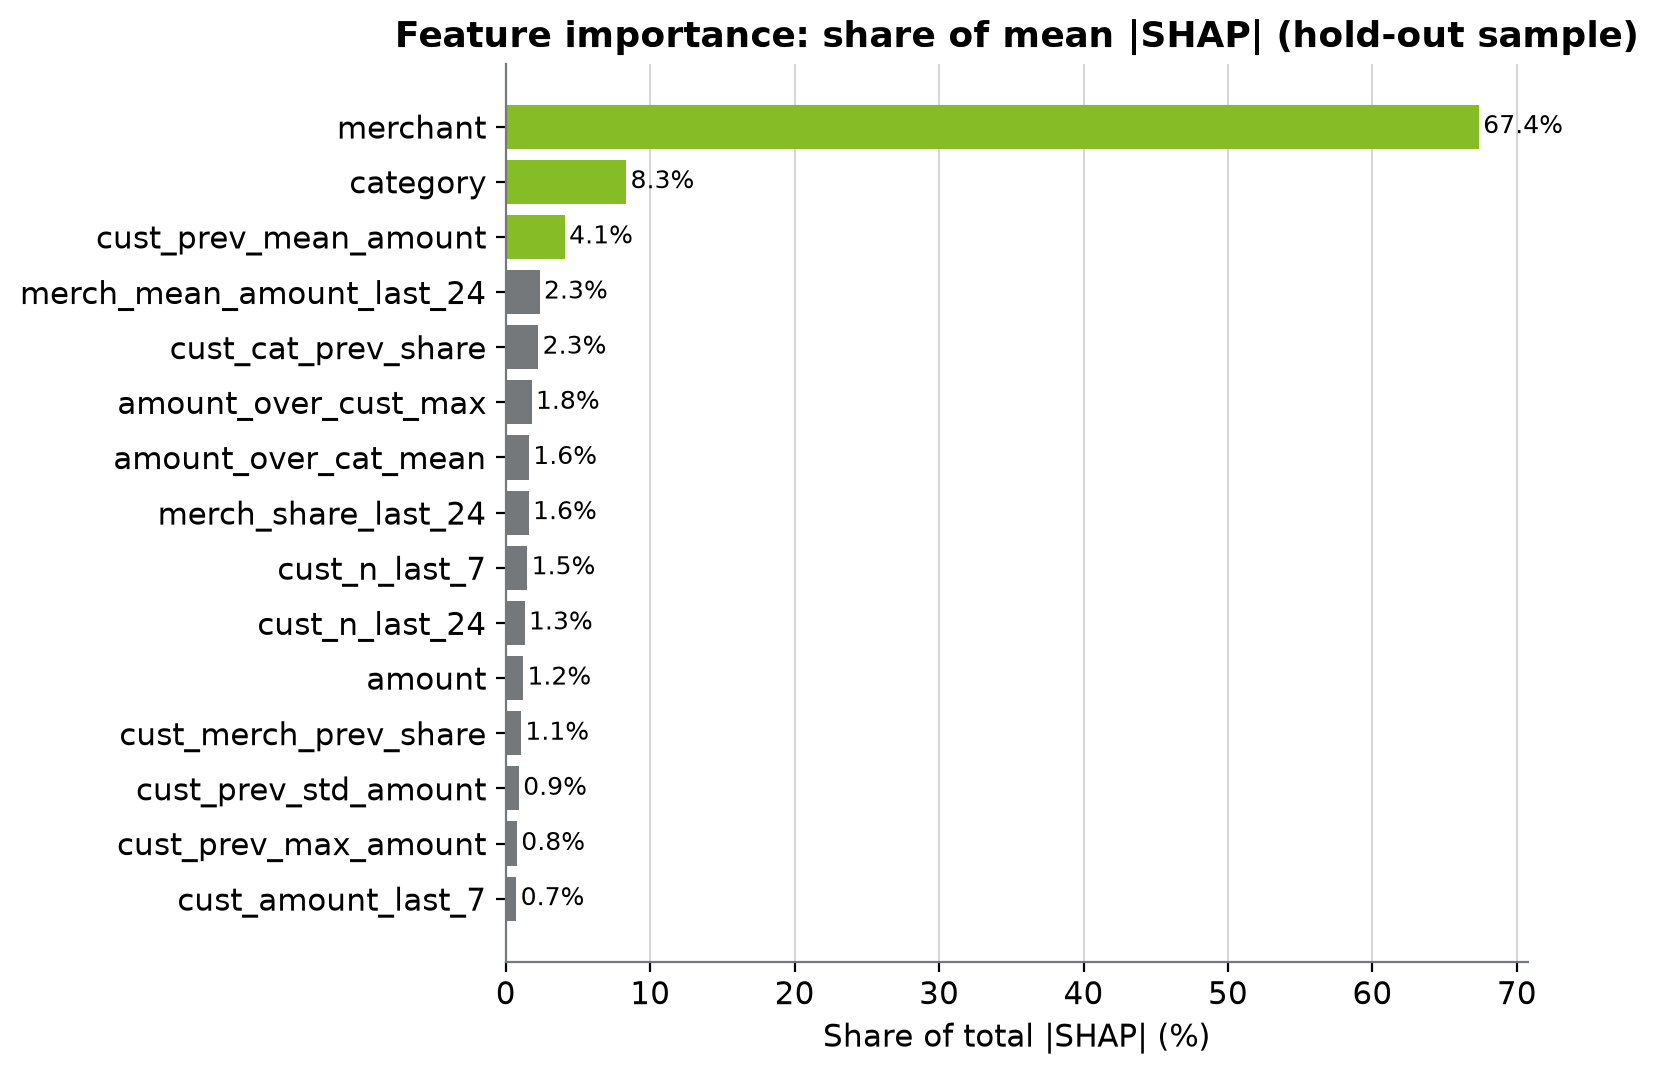

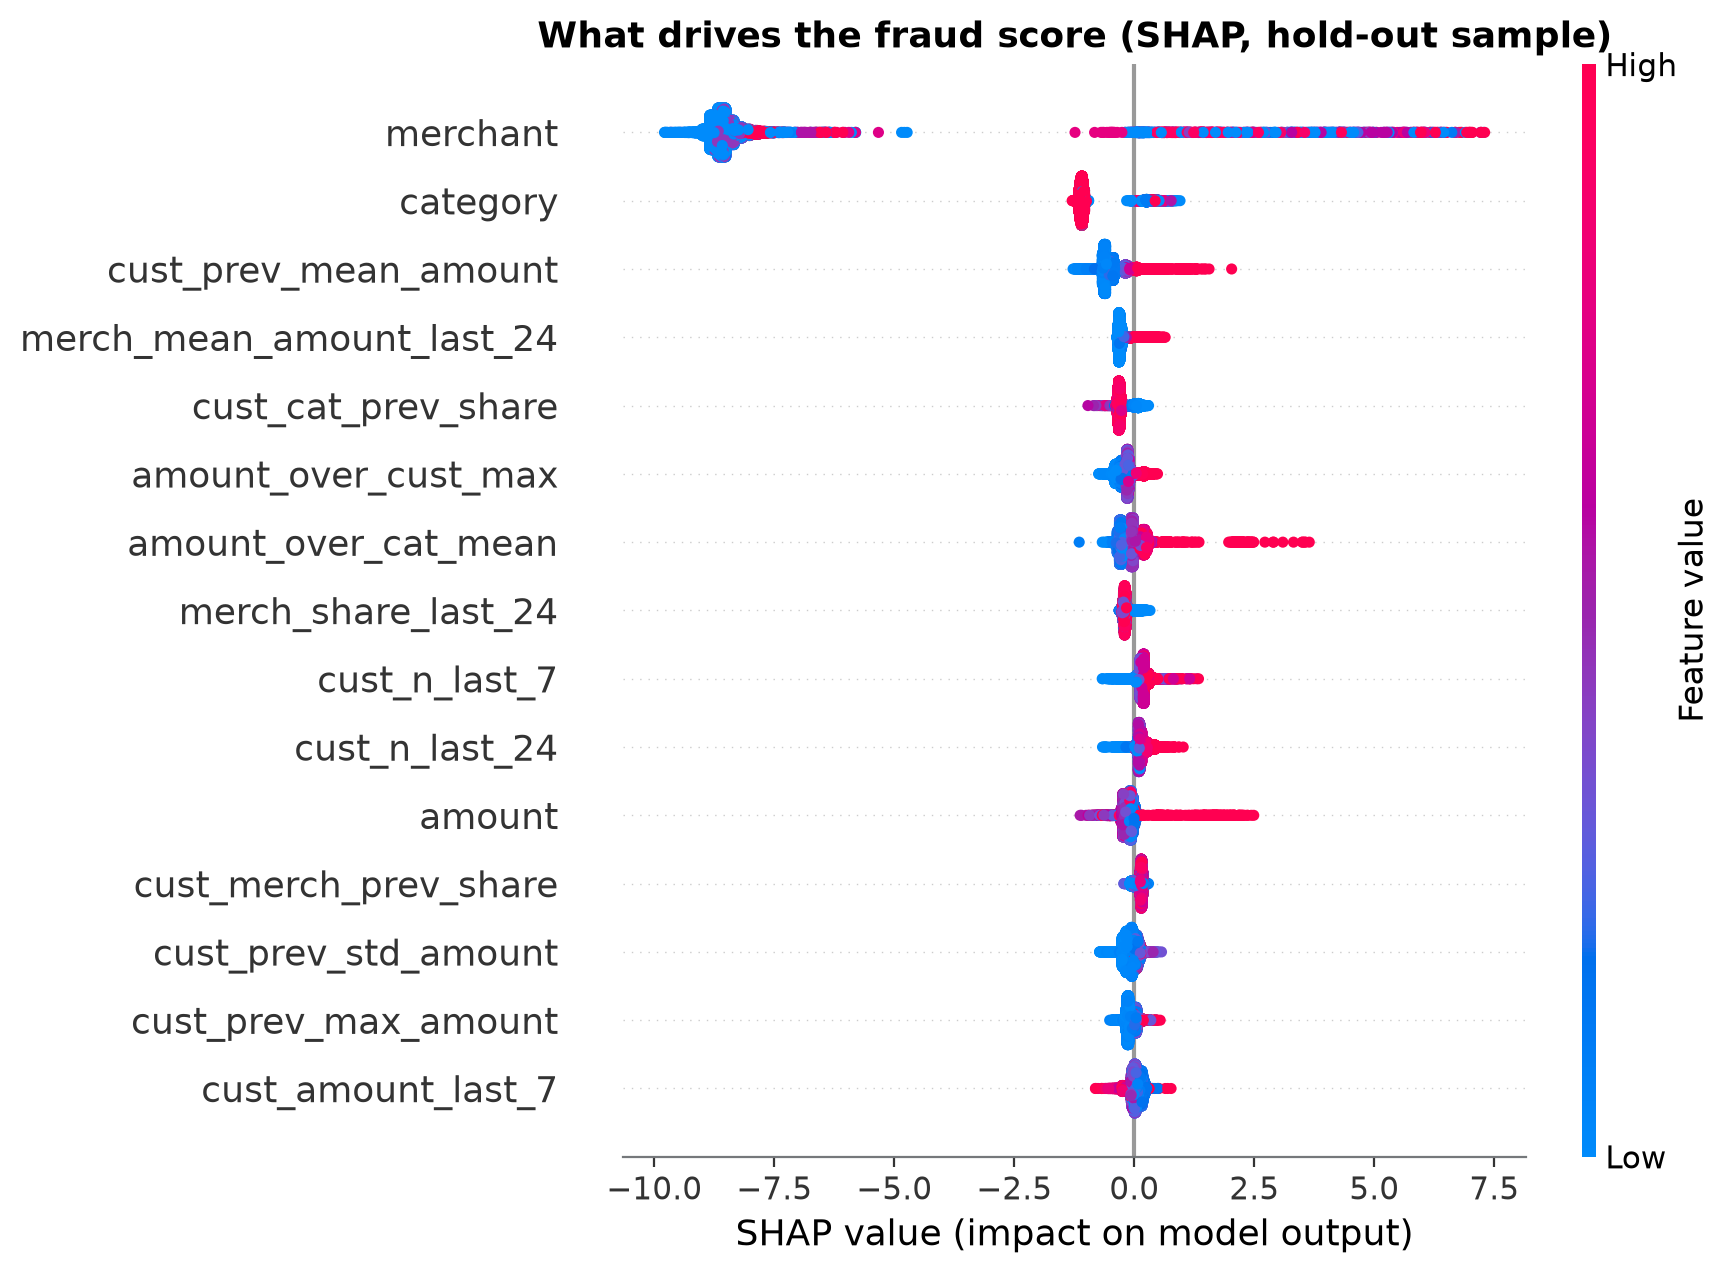

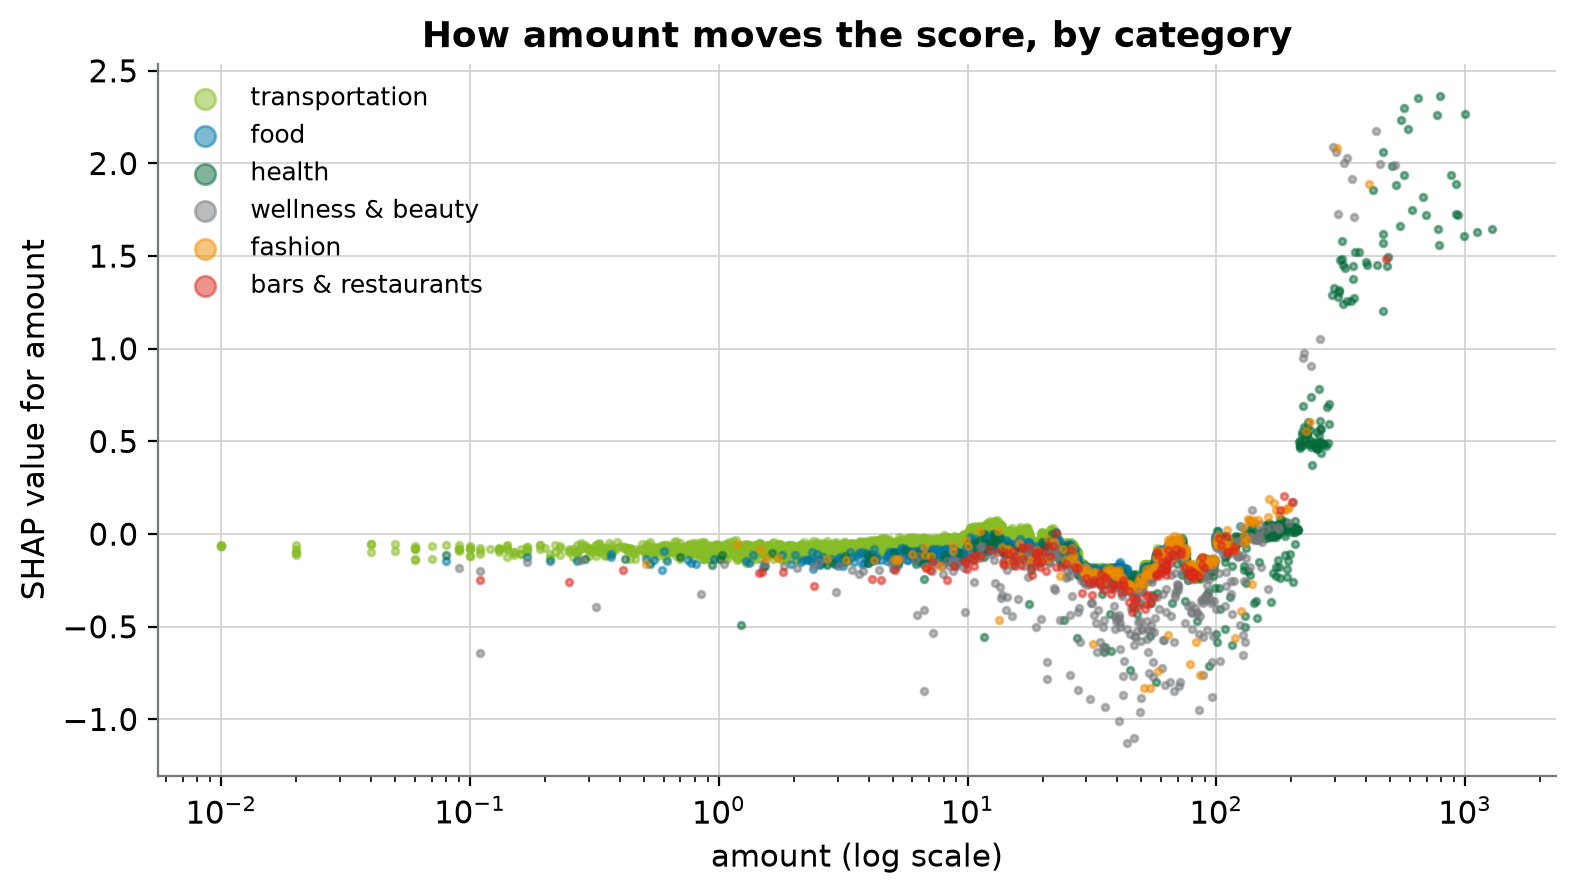

In [4]:
display(Image(FIG / "interp_shap_bar.png"))
display(Image(FIG / "interp_shap_summary.png"))
display(Image(FIG / "interp_shap_dependence_amount.png"))

## 2. Local explanations

Each alert can ship with its top reasons. Below: a true positive, the highest-scoring false positive and the highest-scoring miss.

true_positive   score=0.990 label=1 amount=477.81
    merchant                   = M17379832      shap=+5.70
    amount                     = 477.81         shap=+1.63
    category                   = es_sportsandtoys shap=+0.56
    amount_over_cat_mean       = 1.936          shap=+0.42
    merch_mean_amount_last_24  = 282.87         shap=+0.34


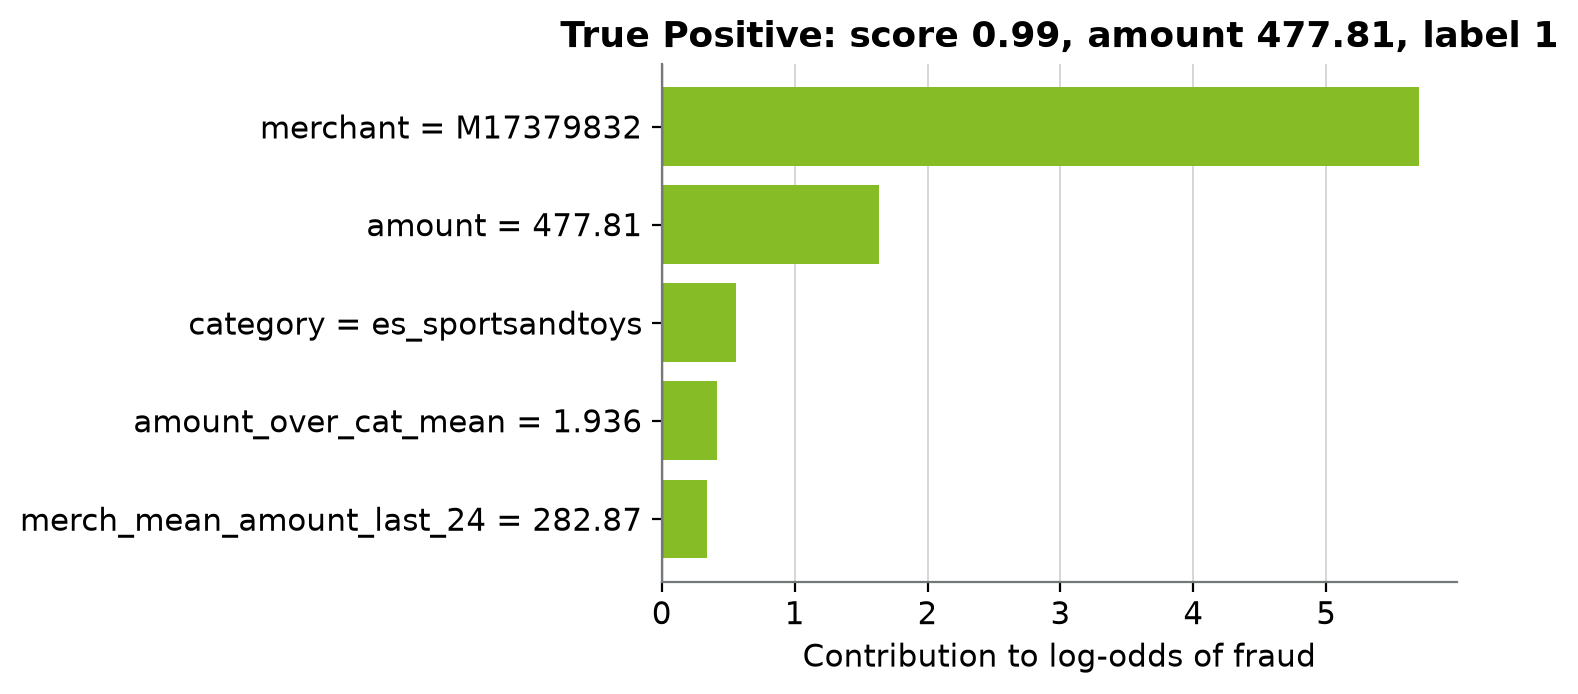

false_positive  score=0.981 label=0 amount=260.12
    merchant                   = M1535107174    shap=+3.17
    amount_over_cat_mean       = 3.828          shap=+3.16
    amount                     = 260.12         shap=+1.16
    category                   = es_wellnessandbeauty shap=+0.54
    cust_n_last_7              = 0.0            shap=-0.30


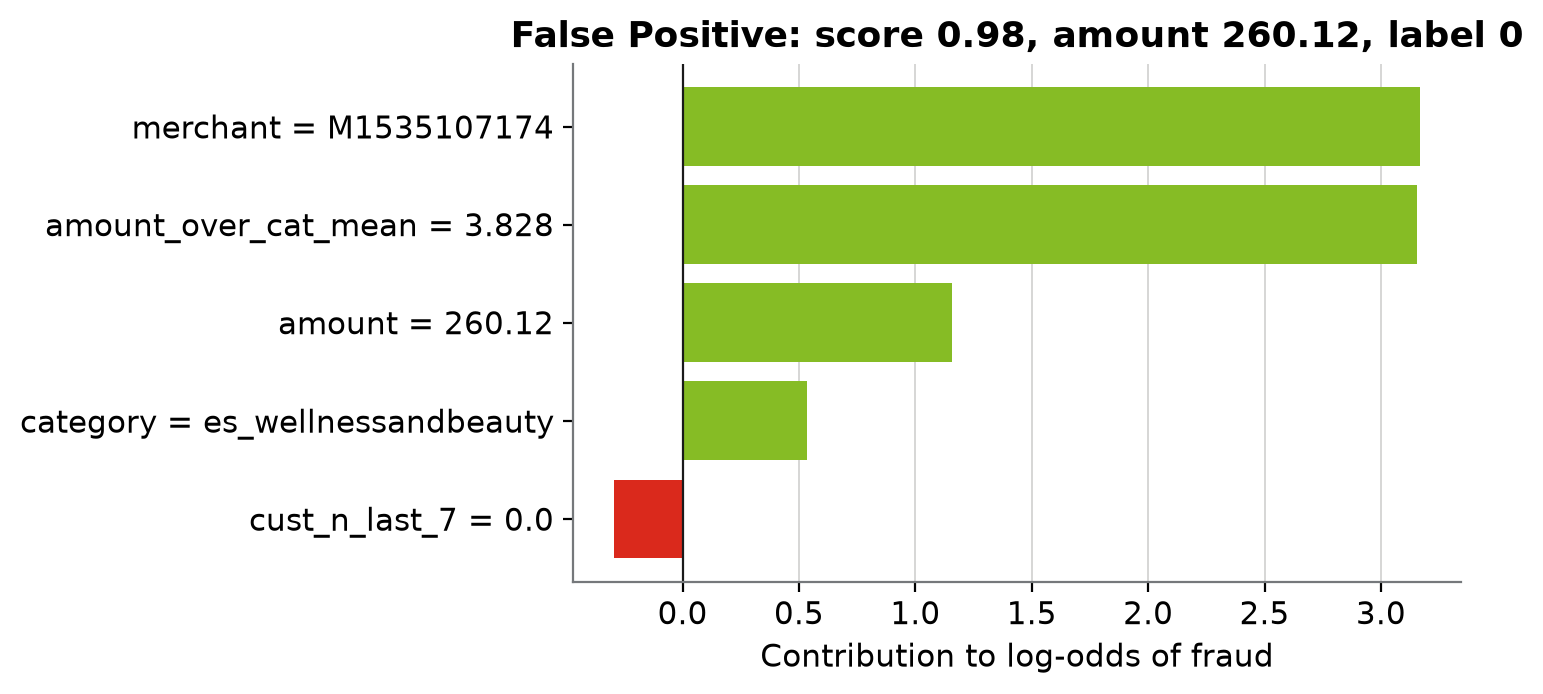

false_negative  score=0.158 label=1 amount=291.46
    merchant                   = M840466850     shap=+1.79
    amount                     = 291.46         shap=+0.67
    amount_over_cust_max       = 1.465          shap=+0.37
    cust_prev_max_amount       = 198.0          shap=-0.36
    cust_n_last_7              = 7.0            shap=+0.32


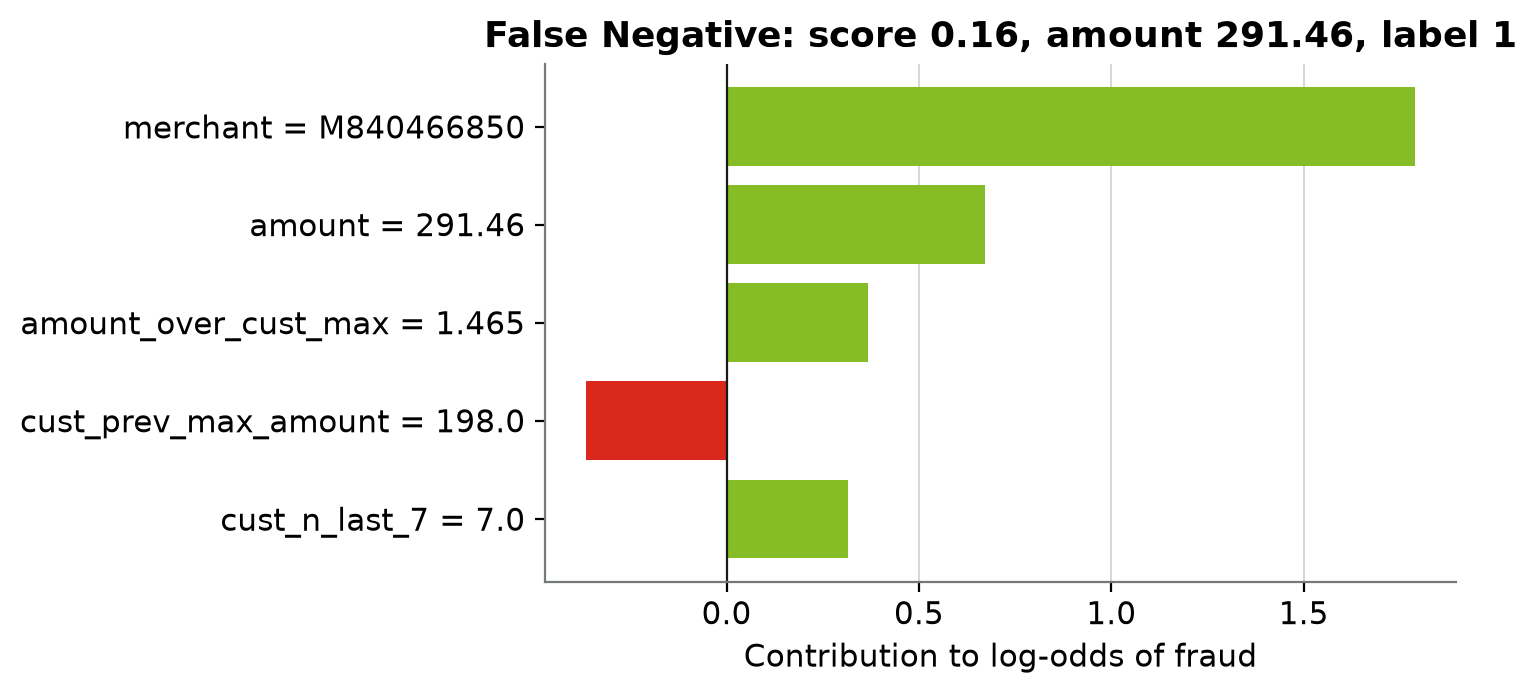

In [5]:
for ex in R["interpretation"]["local_examples"]:
    print(f"{ex['kind']:15s} score={ex['score']:.3f} label={ex['label']} amount={ex['amount']:,.2f}")
    for drv in ex["drivers"]:
        print(f"    {drv['feature']:26s} = {str(drv['value']):14s} shap={drv['shap']:+.2f}")
    display(Image(FIG / f"interp_local_{ex['kind']}.png"))

## 3. Protected attributes and group outcomes

The champion trained with and without `age` and `gender` performs the same, so the production model excludes them. Outcomes by group at the operating threshold are still monitored: alert rates track the underlying fraud rate (women have a higher fraud rate in this data), and the false-positive rate gap between women and men is small but non-zero. Because the model never sees gender, the gap comes from category and spending mix; it is a monitoring item, not a model input.

In [6]:
pr = R["protected"]
print(pd.DataFrame({"with": pr["with"], "without": pr["without"]}))
print("\nDecision:", pr["decision"])

                    with  without
average_precision 0.9578   0.9577
roc_auc           0.9992   0.9992

Decision: Exclude age and gender from the production model: the precision cost is negligible and the regulatory/reputational risk is not.


,n,fraud_rate,alert_rate,precision,recall,false_positive_rate,alert_rate_ratio_vs_largest_group
group,,,,,,,
E,275,0.36%,0.36%,100.0%,100.0%,0.00%,0.23
F,"72,926",1.30%,1.60%,76.8%,94.9%,0.38%,1.00
M,"59,930",0.82%,1.06%,72.0%,92.5%,0.30%,0.66
U,100,0.00%,0.00%,0.0%,0.0%,0.00%,0.00


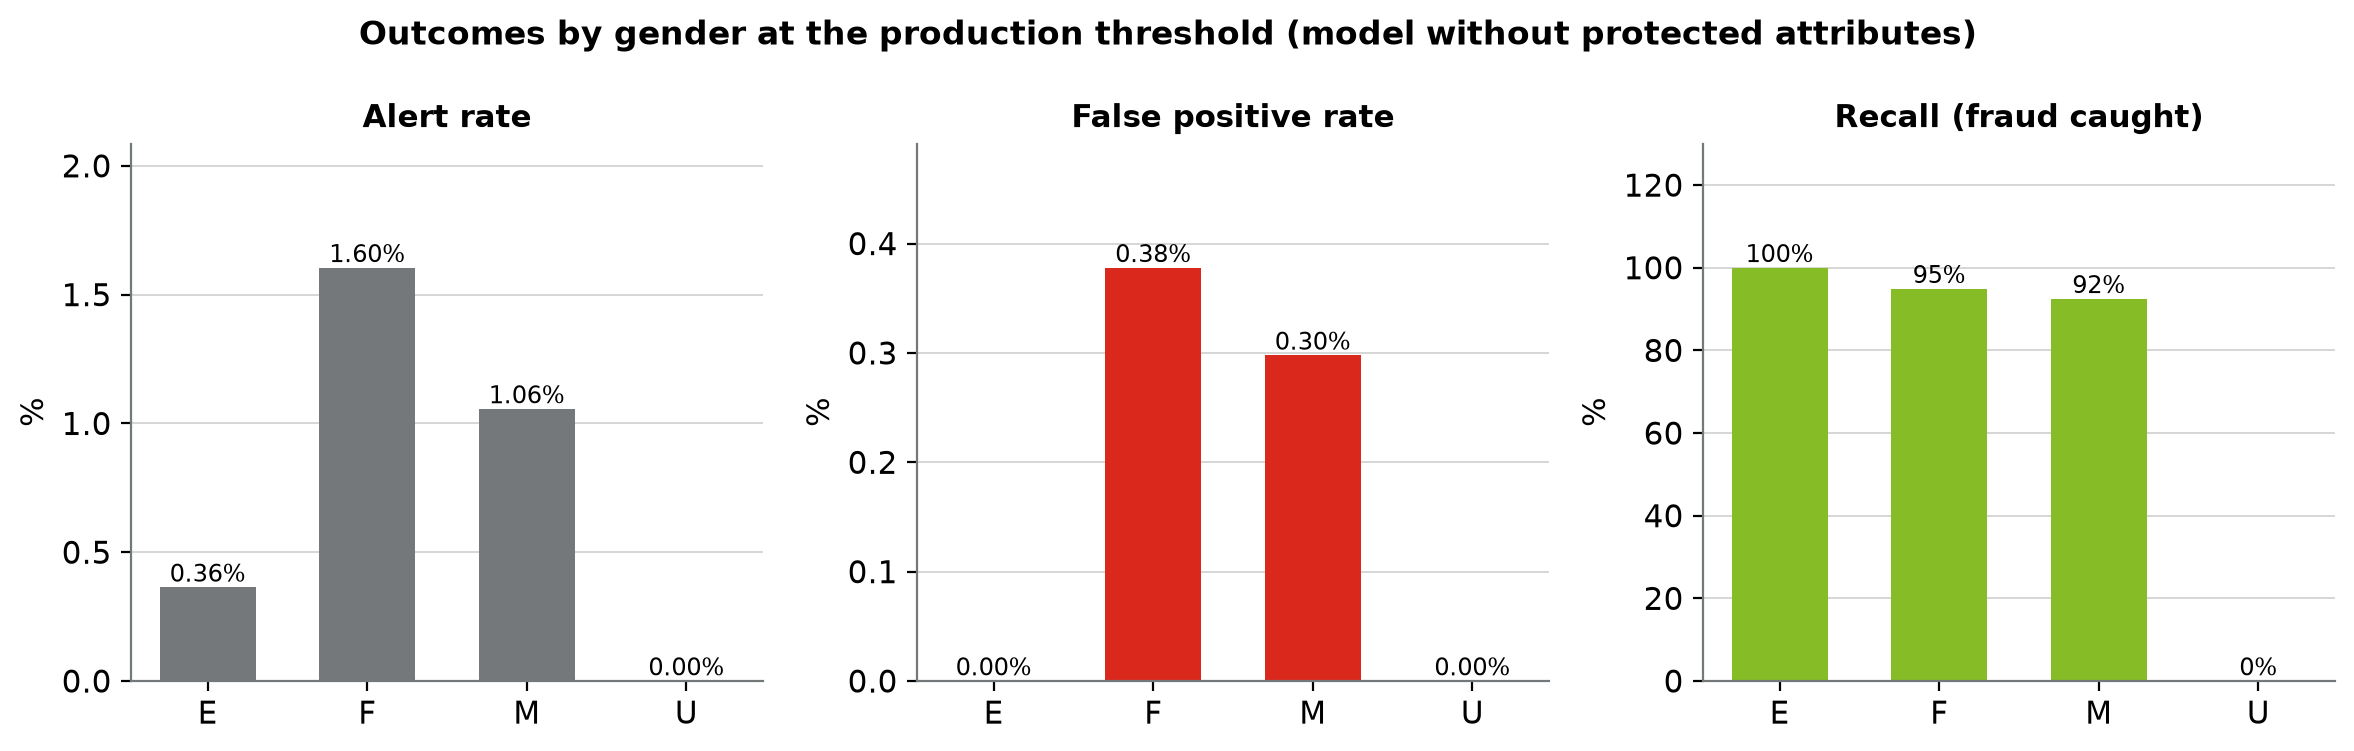

,n,fraud_rate,alert_rate,precision,recall,false_positive_rate,alert_rate_ratio_vs_largest_group
group,,,,,,,
0,629,1.59%,1.91%,83.3%,100.0%,0.32%,1.33
1,"12,919",1.42%,1.76%,77.6%,96.2%,0.40%,1.23
2,"41,618",1.16%,1.44%,75.9%,94.4%,0.35%,1.00
3,"33,310",0.95%,1.26%,71.7%,95.0%,0.36%,0.88
4,"24,603",1.15%,1.37%,77.4%,92.2%,0.31%,0.95
5,"13,874",0.82%,1.05%,72.4%,92.1%,0.29%,0.73
6,"6,003",0.85%,1.07%,73.4%,92.2%,0.29%,0.74
U,275,0.36%,0.36%,100.0%,100.0%,0.00%,0.25


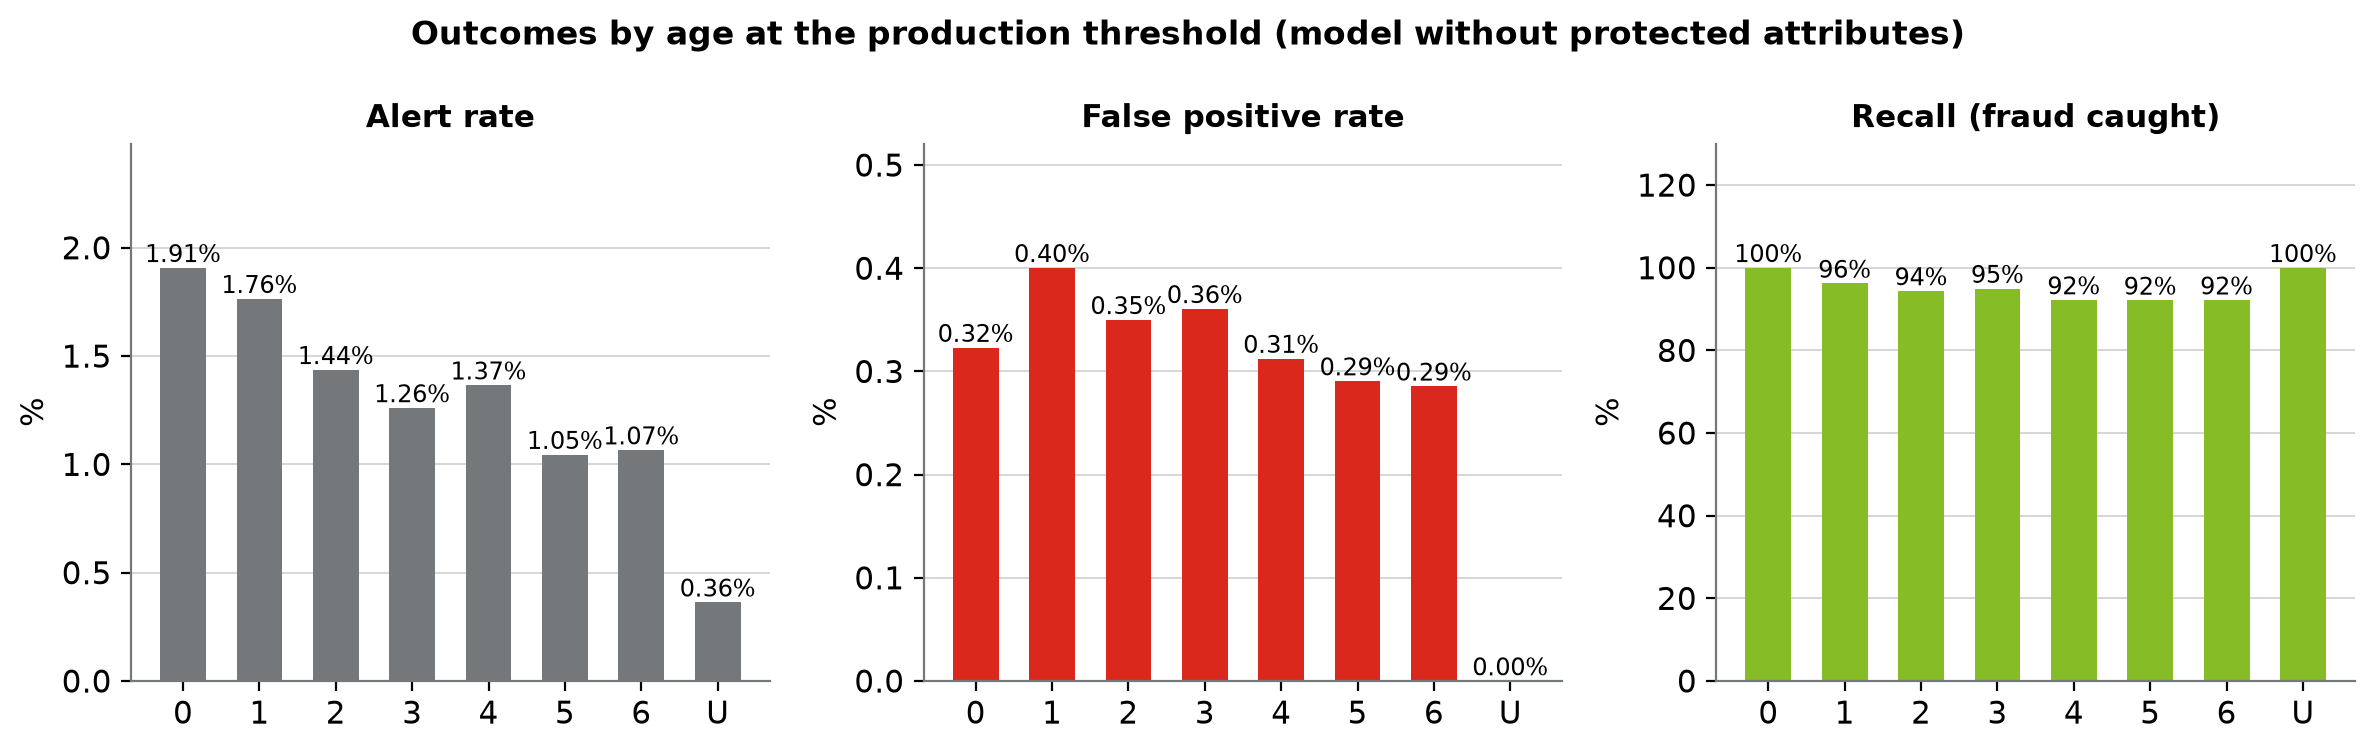

In [7]:
for col in ["gender", "age"]:
    t = pd.DataFrame(R["fairness"][col]["production_model"]).set_index("group")
    display(t.style.format({"fraud_rate": "{:.2%}", "alert_rate": "{:.2%}", "precision": "{:.1%}", "recall": "{:.1%}", "false_positive_rate": "{:.2%}", "alert_rate_ratio_vs_largest_group": "{:.2f}", "n": "{:,}"}))
    display(Image(FIG / f"fair_{col}_outcomes.png"))

## 3b. Where the model is weak, and how sure we are

Performance by category and by amount band at the operating threshold, plus 95% bootstrap intervals for the headline hold-out metrics.

In [8]:
cols = ["segment", "n", "fraud", "alerts", "precision", "recall", "false_positive_rate", "value_recall"]
display(pd.DataFrame(R["segments"]["category"])[cols].head(10).style.format({"precision": "{:.1%}", "recall": "{:.1%}", "false_positive_rate": "{:.2%}", "value_recall": "{:.1%}", "n": "{:,}"}))
display(pd.DataFrame(R["segments"]["amount_band"])[cols].style.format({"precision": "{:.1%}", "recall": "{:.1%}", "false_positive_rate": "{:.2%}", "value_recall": "{:.1%}", "n": "{:,}"}))
ci = R["production"]["bootstrap_ci"]
pd.DataFrame({k: ci[k] for k in ["roc_auc", "average_precision", "precision", "recall", "value_recall"]}).T

,segment,n,fraud,alerts,precision,recall,false_positive_rate,value_recall
0,es_sportsandtoys,594,344,406,84.0%,99.1%,26.00%,99.8%
1,es_health,"4,079",336,443,73.8%,97.3%,3.10%,99.3%
2,es_wellnessandbeauty,"2,978",170,271,54.6%,87.1%,4.38%,96.9%
3,es_hotelservices,386,128,137,90.5%,96.9%,5.04%,99.4%
4,es_travel,127,114,125,91.2%,100.0%,84.62%,100.0%
5,es_leisure,88,88,88,100.0%,100.0%,0.00%,100.0%
6,es_hyper,889,64,85,52.9%,70.3%,4.85%,90.2%
7,es_home,418,54,60,80.0%,88.9%,3.30%,96.7%
8,es_otherservices,116,48,63,66.7%,87.5%,30.88%,97.0%
9,es_tech,559,38,57,61.4%,92.1%,4.22%,96.5%


,segment,n,fraud,alerts,precision,recall,false_positive_rate,value_recall
0,250-500,707,467,489,95.1%,99.6%,10.00%,99.7%
1,500+,380,374,380,98.4%,100.0%,100.00%,100.0%
2,100-250,"3,428",358,519,64.5%,93.6%,5.99%,95.1%
3,0-50,"110,738",138,210,47.6%,72.5%,0.10%,71.3%
4,50-100,"17,978",103,206,39.3%,78.6%,0.70%,78.7%


,low,high
roc_auc,0.9991,0.9994
average_precision,0.9521,0.9649
precision,0.7306,0.7675
recall,0.9262,0.9515
value_recall,0.9879,0.9937


## 4. Business outcomes versus the rules baseline

Same hold-out period, same cost assumptions. Reported per 10,000 transactions so the figures do not depend on whether a step is an hour or a day.

In [9]:
prod, rules = R["production"]["decision"], R["models"]["rules"]["decision"]
k = 10000 / R["split"]["test_rows"]
tbl = pd.DataFrame({
    "rules baseline": {"alerts": rules["n_alerts"] * k, "false declines": rules["fp"] * k, "frauds caught": rules["tp"] * k, "frauds missed": rules["fn"] * k, "recall": rules["recall"], "fraud value stopped": rules["value_recall"], "precision": rules["precision"], "net benefit": rules["net_benefit"] * k},
    "production model": {"alerts": prod["n_alerts"] * k, "false declines": prod["fp"] * k, "frauds caught": prod["tp"] * k, "frauds missed": prod["fn"] * k, "recall": prod["recall"], "fraud value stopped": prod["value_recall"], "precision": prod["precision"], "net benefit": prod["net_benefit"] * k},
})
tbl["change"] = tbl["production model"] - tbl["rules baseline"]
tbl.round(3)

,rules baseline,production model,change
alerts,164.9020,135.4040,-29.4980
false declines,79.6360,33.7010,-45.9350
frauds caught,85.2650,101.7030,16.4380
frauds missed,22.8180,6.3800,-16.4380
recall,0.7890,0.9410,0.1520
fraud value stopped,0.9630,0.9910,0.0290
precision,0.5170,0.7510,0.2340
net benefit,"51,514.4290","53,702.4770","2,188.0480"


## 5. Recommendations (summary)

Now (0-3 months): a shadow-mode pilot as decision support; the threshold set from real analyst capacity and the real cost of a false decline; step-up authentication in the risky categories as a quick win; block and reissue on confirmed fraud; age and gender left out; the model card and leakage checks as the release gate.

Next (3-6 months): device, channel, authentication, geolocation and merchant-risk signals; a label feedback loop that handles chargeback delay; a feature store for the point-in-time features; a champion-challenger cycle; fairness monitoring.

Later (6-12 months): real-time scoring with fallback rules; automation of low-risk decisions only where precision is proven; account- and network-level features; calibration; independent validation before any automated decline.